# Process (prepare_cohort.sh)

In [1]:
import argparse
import os

import anndata as ad

from methyltrain.config.loader import load_config
from methyltrain.fs.layout import CohortLayout
from methyltrain.api.steps import (
    cohort_batch_correction, 
    load_processed_project,
    aggregate_cohort,
    cohort_batch_correction,
    save_cohort,
    split
)

config = "/ddn_exa/campbell/sli/methyltrain/config/pancancer_config.yaml"

In [2]:
# Load the user-provided configurations
config = load_config(config)
cohort = config.get('project_id', '')

In [3]:
# Initialize the projects provided in the configurations
project_dir = config.get('project_dir', '')
all_projects = config.get('projects', [])
project_list = []
for project in all_projects:
    project_list.append(os.path.join(project_dir, f"{project}_adata.h5ad"))

In [4]:
# Initialize the default cohort layout
layout = CohortLayout(
    cohort_name = cohort,
    root_dir = "./data",
    project_list = project_list,
    cohort_adata = f"../data/training/{cohort}_cohort_adata.h5ad",
    train_adata = f"../data/training/{cohort}_train_adata.h5ad",
    val_adata = f"../data/training/{cohort}_val_adata.h5ad",
    test_adata = f"../data/training/{cohort}_test_adata.h5ad"
)
layout.initialize()
layout.validate()

In [5]:
# Load each processed project AnnData object
project_adatas = [load_processed_project(path) 
                  for path in layout.project_list]

In [7]:
# Aggregate the projects into a cohort AnnData object
cohort_adata = aggregate_cohort(project_adatas, layout)

In [8]:
# Save the aggregated cohort
save_cohort(cohort_adata, layout)

In [9]:
# Split and save the cohort into train-val-test splits
train_adata, val_adata, test_adata = split(cohort_adata, config)
train_adata.write_h5ad(layout.train_adata)
val_adata.write_h5ad(layout.val_adata)
test_adata.write_h5ad(layout.test_adata)

# Evaluate

In [15]:
import scanpy as sc
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

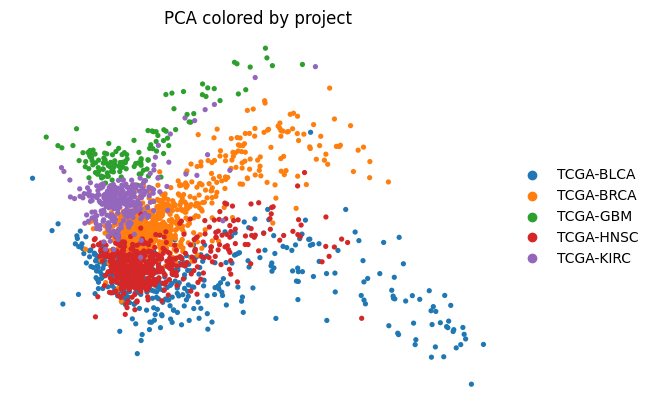

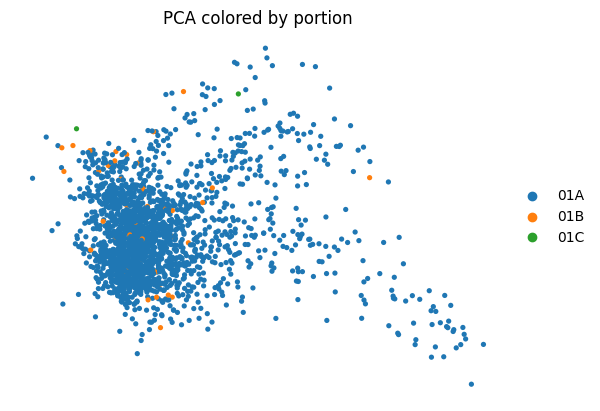

Variance fraction explained by project: 0.47584784
Variance fraction explained by portion: 0.56994265


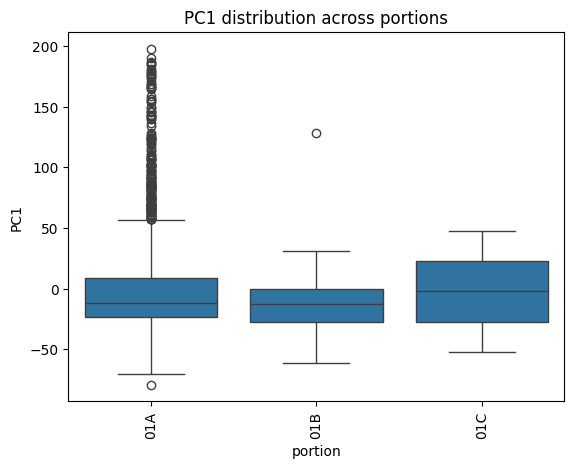

NameError: name 'plot' is not defined

In [22]:
import scanpy as sc
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.figdir = "/ddn_exa/campbell/sli/methyltrain/plots"

# --------------------------
# 1. Subset to highly variable CpGs
# --------------------------
sc.pp.highly_variable_genes(cohort_adata, n_top_genes=5000, flavor="seurat")
adata_var = cohort_adata[:, cohort_adata.var['highly_variable']].copy()

# Standardize features
sc.pp.scale(adata_var, max_value=10)

# Extract portion
adata_var.obs['portion'] = adata_var.obs['batch_id'].str.split('-').str[0]

# --------------------------
# 2. PCA
# --------------------------
sc.tl.pca(adata_var, n_comps=10)

# Store PCA in DataFrame for analysis
pcs_df = pd.DataFrame(
    adata_var.obsm['X_pca'],
    index=adata_var.obs_names,
    columns=[f'PC{i+1}' for i in range(adata_var.obsm['X_pca'].shape[1])]
)
pcs_df = pcs_df.join(adata_var.obs[['batch_id', 'project_id']])

# --------------------------
# 3. Aggregate batches within project (optional)
# --------------------------
# Extract portion from batch_id (portion-plate)
pcs_df['portion'] = pcs_df['batch_id'].str.split('-').str[0]

# --------------------------
# 4. Visualize PCA colored by project and portion
# --------------------------
sc.pl.pca(
    adata_var,
    color='project_id',
    components=['1,2'],
    frameon=False,
    title="PCA colored by project",
    save="_project.png"
)

# Portion overlay (aggregated across all projects)
sc.pl.pca(
    adata_var,
    color='portion',
    components=['1,2'],
    frameon=False,
    title="PCA colored by portion",
    save="_portion.png"
)

# --------------------------
# 5. Variance explained by batch vs project (quantitative)
# --------------------------
pcs_numeric = pcs_df[[f'PC{i+1}' for i in range(adata_var.obsm['X_pca'].shape[1])]]

def fraction_variance(df_numeric, factor_series):
    """Fraction of variance in numeric PCs explained by a categorical factor."""
    grouped = df_numeric.groupby(factor_series).mean()
    return grouped.var().sum() / df_numeric.var().sum()

# Example usage:
fv_project = fraction_variance(pcs_numeric, pcs_df['project_id'])
fv_portion = fraction_variance(pcs_numeric, pcs_df['portion'])

print("Variance fraction explained by project:", fv_project)
print("Variance fraction explained by portion:", fv_portion)

# --------------------------
# 6. Optional: PC distributions per portion (boxplot)
# --------------------------
sns.boxplot(x='portion', y='PC1', data=pcs_df)
plt.xticks(rotation=90)
plt.title("PC1 distribution across portions")
plt.show()

In [18]:
ad.read_h5ad("../data/training/pancancer_cohort_adata.h5ad")

AnnData object with n_obs × n_vars = 2118 × 225410
    obs: 'file_name', 'data_type', 'data_category', 'experimental_strategy', 'platform', 'project_id', 'submitter_id', 'sample_type', 'aliquot_id', 'status', 'barcode', 'batch_id', 'missing_rate', 'mean'
    uns: 'cohort_id', 'conversion', 'data_type', 'level', 'platform', 'preprocessing_steps', 'projects', 'reference_genome', 'state'

In [19]:
ad.read_h5ad("../data/training/pancancer_train_adata.h5ad")

AnnData object with n_obs × n_vars = 1355 × 225410
    obs: 'file_name', 'data_type', 'data_category', 'experimental_strategy', 'platform', 'project_id', 'submitter_id', 'sample_type', 'aliquot_id', 'status', 'barcode', 'batch_id', 'missing_rate', 'mean'
    uns: 'cohort_id', 'conversion', 'data_type', 'level', 'platform', 'preprocessing_steps', 'projects', 'reference_genome', 'split', 'split_percentage', 'state'

In [20]:
ad.read_h5ad("../data/training/pancancer_val_adata.h5ad")

AnnData object with n_obs × n_vars = 339 × 225410
    obs: 'file_name', 'data_type', 'data_category', 'experimental_strategy', 'platform', 'project_id', 'submitter_id', 'sample_type', 'aliquot_id', 'status', 'barcode', 'batch_id', 'missing_rate', 'mean'
    uns: 'cohort_id', 'conversion', 'data_type', 'level', 'platform', 'preprocessing_steps', 'projects', 'reference_genome', 'split', 'split_percentage', 'state'

In [21]:
ad.read_h5ad("../data/training/pancancer_test_adata.h5ad")

AnnData object with n_obs × n_vars = 424 × 225410
    obs: 'file_name', 'data_type', 'data_category', 'experimental_strategy', 'platform', 'project_id', 'submitter_id', 'sample_type', 'aliquot_id', 'status', 'barcode', 'batch_id', 'missing_rate', 'mean'
    uns: 'cohort_id', 'conversion', 'data_type', 'level', 'platform', 'preprocessing_steps', 'projects', 'reference_genome', 'split', 'split_percentage', 'state'